In [2]:
import pandas as pd

import matplotlib.pyplot as plt

from nltk.sentiment import SentimentIntensityAnalyzer

import nltk

plt.style.use("ggplot")

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\prata\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
df = pd.read_csv(
    "../data/processed/reddit_posts_cleaned.csv"
)

sia = SentimentIntensityAnalyzer()

In [4]:
def get_sentiment(text):

    score = sia.polarity_scores(text)

    compound = score["compound"]

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    return "Neutral"


def get_score(text):

    return sia.polarity_scores(text)["compound"]


df["sentiment"] = df["clean_title"].apply(
    get_sentiment
)

df["score"] = df["clean_title"].apply(
    get_score
)

df.head()

,keyword,title,subreddit,timestamp,post_url,scrape_date,batch_number,source,clean_title,location,skill,role,sentiment,score
0,developersindia hiring,How's Infosys for starters 😳,r/IndiaTech,2026-03-10T07:42:32+00:00,https://old.reddit.com/r/IndiaTech/comments/1r...,NaN,NaN,NaN,hows infosys for starters,Unknown,Unknown,Software Engineer,Neutral,0.0
1,developersindia hiring,Who's hiring? - Monthly Megathread - June 2026,r/developersIndia,2026-06-01T04:32:05+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread june 2026,Unknown,Unknown,Software Engineer,Neutral,0.0
2,developersindia hiring,Who's hiring? - Monthly Megathread - February ...,r/developersIndia,2026-02-01T04:32:29+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread february 2026,Unknown,Unknown,Software Engineer,Neutral,0.0
3,developersindia hiring,Who's looking for work? - Monthly Megathread -...,r/developersIndia,2026-06-01T04:30:14+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos looking for work monthly megathread june ...,Unknown,Unknown,Software Engineer,Neutral,0.0
4,developersindia hiring,Who's hiring? - Monthly Megathread - May 2026,r/developersIndia,2026-05-01T04:32:13+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread may 2026,Unknown,Unknown,Software Engineer,Neutral,0.0


# Graph 1 — Sentiment Distribution

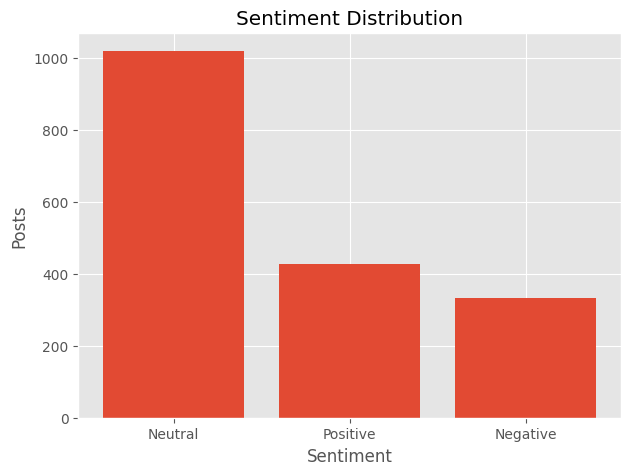

In [5]:
counts = df["sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    counts.index,
    counts.values
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Posts")

plt.show()

# Graph 2 — Pie Chart

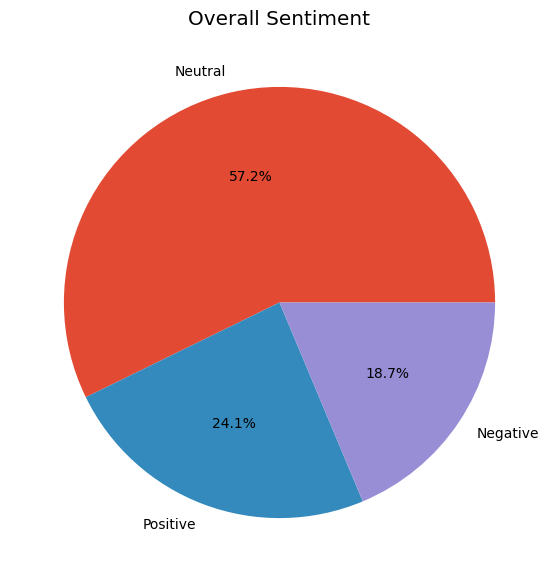

In [6]:
plt.figure(figsize=(7,7))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%"
)

plt.title("Overall Sentiment")

plt.show()

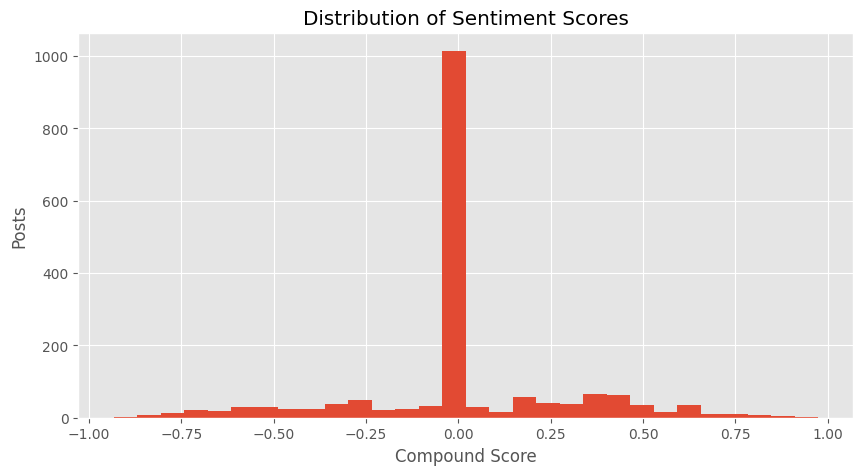

In [7]:
plt.figure(figsize=(10,5))

plt.hist(
    df["score"],
    bins=30
)

plt.title("Distribution of Sentiment Scores")

plt.xlabel("Compound Score")

plt.ylabel("Posts")

plt.show()

# Graph 4 — Average Sentiment by Role

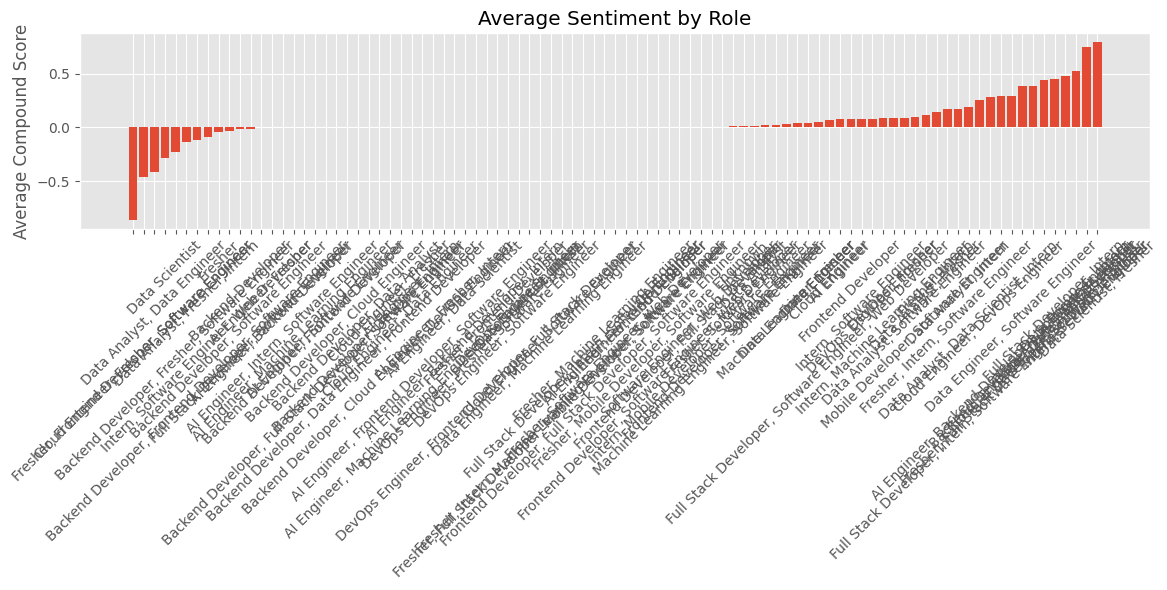

In [8]:
role_sentiment = (
    df.groupby("role")["score"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

plt.bar(
    role_sentiment.index,
    role_sentiment.values
)

plt.xticks(rotation=45)

plt.title("Average Sentiment by Role")

plt.ylabel("Average Compound Score")

plt.tight_layout()

plt.show()

# Graph 5 — Average Sentiment by Skill

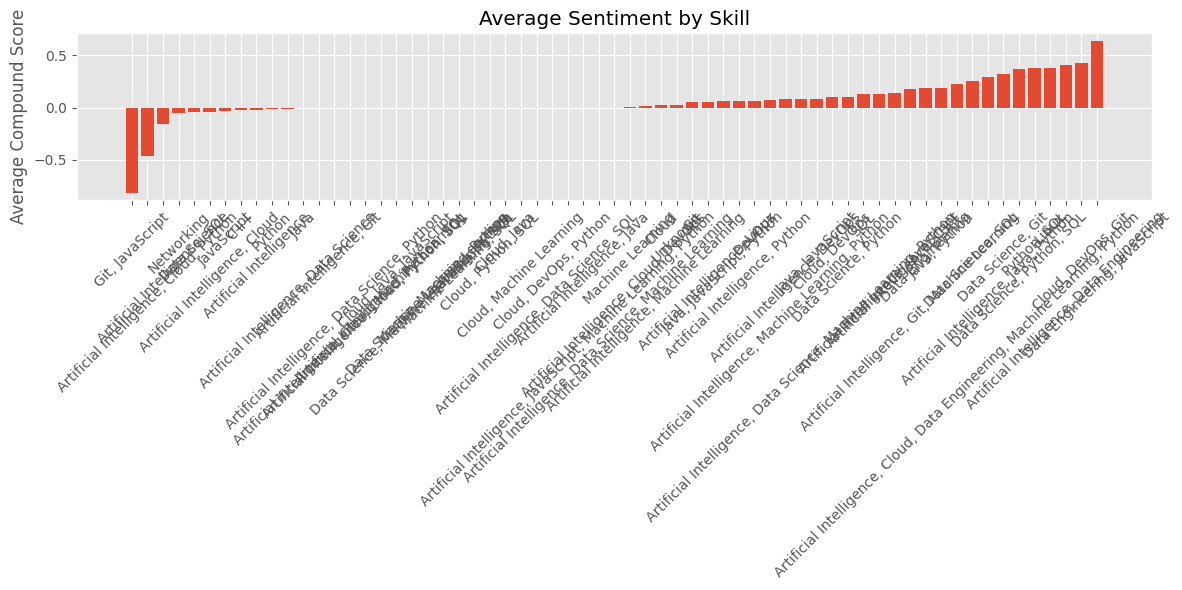

In [9]:
skill_sentiment = (
    df.groupby("skill")["score"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))

plt.bar(
    skill_sentiment.index,
    skill_sentiment.values
)

plt.xticks(rotation=45)

plt.title("Average Sentiment by Skill")

plt.ylabel("Average Compound Score")

plt.tight_layout()

plt.show()

In [10]:
negative = df.sort_values(
    "score"
).head(20)

negative[
    [
        "title",
        "score"
    ]
]

,title,score
1277,"""Scam Warning ""Fake Job scam in Pune held loca...",-0.9337
1358,"24M in Mumbai. Lost both my parents, stuck in ...",-0.8807
1489,NEW: The long-running campus sexual harassment...,-0.8750
225,[Resume Review] 2 YOE Frontend Developer (Reac...,-0.8555
928,"After a 45 hour weekend night shift, I was fir...",-0.8555
534,"25M from India, drowning in debt and confused ...",-0.8316
125,Deloitte NLA shortlisting mails are out. Most ...,-0.8255
1322,Multiple Indian subreddits discuss a recent ca...,-0.8126
54,Bengaluru software engineer loses whopping Rs ...,-0.8126
1171,Accenture sued over website redesign so bad it...,-0.8122


In [11]:
positive = df.sort_values(
    "score",
    ascending=False
).head(20)

positive[
    [
        "title",
        "score"
    ]
]

,title,score
818,[Charania] on who the Knicks might hire as the...,0.9744
822,[NFL] Upon being hired as the new HC of the NY...,0.9062
536,Which is the best platform for find a good Job...,0.9022
889,Introducing Centreum Network Amazing and Exper...,0.8944
813,The Minnesota Vikings defends the hiring of th...,0.8910
1218,COGNIZANT IS HIRING CONTRACTUAL 25K COMPLETION...,0.8481
1210,COGNIZANT IS HIRING CONTRACTUAL 25K COMPLETION...,0.8481
1532,OpenAI's CEO Sam Altman says in 10 years time ...,0.8244
821,[Krawczynski] “Let’s make it very clear. Marc ...,0.7960
1482,‘Kick Kavanaugh off campus': Students decry Ge...,0.7906


In [12]:
df.to_csv(
    "../data/processed/reddit_posts_sentiment.csv",
    index=False
)